# Стохастический анализ, зима 2026

# Домашнее задание 2: чистовое решение

В ноутбуке собраны решения теоретических листков `HW2_1.pdf`, `HW2_2.pdf`, программной части про робот-пылесос и дополнительной части про верхнюю оценку американского опциона.


## Листок 1. Цепи Маркова в дискретном времени

### Упражнение 1.1

**Задание.** Доказать критерий эргодичности конечной стохастической матрицы: из любой вершины в любую есть путь положительной вероятности, и нет периодических состояний.

**Решение.**

Для конечной цепи первое условие означает неприводимость: все состояния сообщаются. Тогда существует единственное инвариантное распределение $\pi$, и $\pi_i>0$ для всех состояний.

Если дополнительно все состояния апериодичны, то по теореме Перрона-Фробениуса для стохастических матриц единица является простым собственным значением, а все остальные собственные значения по модулю строго меньше $1$. Поэтому
$$
P^n\to \mathbf 1\pi,
$$
то есть распределение $X_n$ сходится к $\pi$ из любого начального состояния. Это и есть эргодичность.

Обратно, если цепь эргодична, то из любого начального состояния она должна сходиться к одному и тому же предельному распределению. Если бы из $i$ нельзя было попасть в $j$, то при старте из $i$ предельная вероятность состояния $j$ не могла бы совпасть с положительной инвариантной массой класса, содержащего $j$. Значит, цепь неприводима. Если бы состояния имели период $d>1$, то вероятности возвращения в состояние осциллировали бы по классам вычетов modulo $d$, и предела $P^n(i,\cdot)$ не существовало бы. Значит, период равен $1$.


### Упражнение 1.2

**Задание.** Для
$$
P=\begin{pmatrix}
1/3&0&2/3\\
1/3&2/3&0\\
1/3&1/3&1/3
\end{pmatrix}
$$
найти $P^n$, инвариантное распределение и проверить эргодичность.

**Решение.**

Инвариантное распределение решается из $\pi P=\pi$, $\sum_i\pi_i=1$:
$$
\pi=\left(\frac13,\frac13,\frac13\right).
$$

Для $n\ge1$:
$$
P^n=
\begin{pmatrix}
1/3&1/3&1/3\\
1/3&1/3&1/3\\
1/3&1/3&1/3
\end{pmatrix}
+\left(\frac13\right)^n
\begin{pmatrix}
0&-1&1\\
0&1&-1\\
0&0&0
\end{pmatrix}.
$$
При $n=0$ отдельно $P^0=I$.

Цепь неприводима: из каждого состояния можно попасть в каждое за конечное число шагов. Она апериодична, потому что у каждого состояния есть возврат за один шаг: $P_{11},P_{22},P_{33}>0$. Значит, цепь эргодична, и $P^n\to \mathbf 1\pi$.


### Упражнение 1.3

**Задание.** Если $X_t$ - независимые одинаково распределенные величины на конечном множестве $\Xi$, можно ли задать процесс как цепь Маркова?

**Решение.**

Да. Пусть
$$
p_j=\mathbb P(X_t=j).
$$
Тогда
$$
\mathbb P(X_{t+1}=j\mid X_t=i)=p_j
$$
для всех $i,j$, потому что $X_{t+1}$ независима от прошлого. Матрица переходов имеет одинаковые строки:
$$
P=\begin{pmatrix}
p_1&p_2&\ldots&p_m\\
p_1&p_2&\ldots&p_m\\
\vdots&\vdots&&\vdots\\
p_1&p_2&\ldots&p_m
\end{pmatrix}.
$$


### Упражнение 1.4

**Задание.** Пусть $Y_t$ - белый шум на $\{-1,1\}$, а
$$
X_t=\frac{Y_{t+1}+Y_t}{2}.
$$
Проверить, является ли $X$ цепью Маркова.

**Решение.**

$X_t$ принимает значения $-1,0,1$. Если $X_t=0$, то возможны два случая:
$$
(Y_t,Y_{t+1})=(1,-1)\quad\text{или}\quad(-1,1).
$$
По одному только значению $X_t=0$ мы не знаем знак $Y_{t+1}$, но прошлое может его раскрыть.

Например,
$$
\mathbb P(X_{t+1}=-1\mid X_t=0)=\frac14.
$$
Но если дополнительно известно, что $X_{t-1}=1$, то $Y_t=1$, а из $X_t=0$ следует $Y_{t+1}=-1$. Тогда
$$
\mathbb P(X_{t+1}=-1\mid X_t=0,X_{t-1}=1)=\frac12.
$$
Условные вероятности различаются, значит марковское свойство нарушается. Процесс $X$ не является цепью Маркова.


### Упражнение 1.5

**Задание.** Случайное блуждание по связному неориентированному графу: из вершины $u$ переход в каждого соседа равновероятен, $p_{uv}=1/k_u$. Доказать существование и найти инвариантное распределение.

**Решение.**

Пусть $k_u$ - степень вершины $u$, а $|E|$ - число ребер. Положим
$$
\pi_u=\frac{k_u}{2|E|}.
$$
Тогда для любого ребра $(u,v)$:
$$
\pi_u p_{uv}=\frac{k_u}{2|E|}\frac1{k_u}=\frac1{2|E|}
=\frac{k_v}{2|E|}\frac1{k_v}=\pi_vp_{vu}.
$$
Выполнено детальное равновесие, значит $\pi$ инвариантно. Граф конечный и связный, поэтому такое распределение существует и единственно. Цепь при этом может быть не эргодической: например, на двудольном графе есть период $2$.


### Упражнение 1.6

**Задание.** ГЛ ставит на первую серию `ООО`, БП - на первую серию `ОРО`. У кого выше шанс победы?

**Решение.**

Обозначим `О` за $H$, `Р` за $T$. Состояния - самые длинные суффиксы, являющиеся префиксами одного из шаблонов: $\varnothing,H,HH,HT$. Пусть $p_s$ - вероятность победы `HHH` из состояния $s$.

Имеем:
$$
p_\varnothing=\frac12p_H+\frac12p_\varnothing,\qquad
p_H=\frac12p_{HH}+\frac12p_{HT},
$$
$$
p_{HH}=\frac12+\frac12p_{HT},\qquad
p_{HT}=\frac12p_\varnothing.
$$
Отсюда $p_\varnothing=0.4$. Значит, вероятность победы ГЛ равна $0.4$, а вероятность победы БП равна $0.6$. Выше шанс у БП.


### Упражнение 1.7

**Задание.** Простое симметричное случайное блуждание на $\mathbb Z$: найти матожидание, дисперсию, ковариацию, проверить эргодичность и возвратность.

**Решение.**

Пусть
$$
X_t=\xi_1+\ldots+\xi_t,\qquad \mathbb P(\xi_i=1)=\mathbb P(\xi_i=-1)=1/2.
$$
Тогда
$$
\mathbb E X_t=0,\qquad \operatorname{Var}(X_t)=t.
$$
Для $s\le t$:
$$
\operatorname{Cov}(X_s,X_t)=\operatorname{Cov}(X_s,X_s+\xi_{s+1}+\ldots+\xi_t)=s.
$$
Значит,
$$
K(s,t)=\min(s,t).
$$

Цепь не эргодична: у нее нет инвариантного вероятностного распределения на $\mathbb Z$, и, кроме того, она периодична с периодом $2$.

Возвратность состояния $0$ следует из критерия
$$
\sum_{n=0}^\infty \mathbb P_0(X_n=0)=\infty.
$$
Возвраты возможны только в четные моменты:
$$
\mathbb P_0(X_{2n}=0)=\binom{2n}{n}2^{-2n}\sim \frac1{\sqrt{\pi n}},
$$
а ряд $\sum_n n^{-1/2}$ расходится. По пространственной однородности все состояния возвратны.


### Упражнение 1.8, бонус

**Задание.** К конечной эргодической цепи добавляют поглощающее состояние $x$, в которое можно попасть из хотя бы одной старой вершины. Доказать сходимость к $x$ и конечность последнего посещения старых состояний.

**Решение.**

В новой цепи $\delta_x$ - инвариантное распределение. Так как исходная цепь конечная и эргодическая, из любого старого состояния можно за ограниченное число шагов попасть в вершину, из которой есть положительная вероятность перехода в $x$. Следовательно, существуют $L$ и $\varepsilon>0$ такие, что из любого старого состояния вероятность попасть в $x$ за следующие $L$ шагов не меньше $\varepsilon$.

Тогда
$$
\mathbb P(\tau_x>kL)\le(1-\varepsilon)^k\to0.
$$
Значит, время попадания в $x$ почти наверное конечно, и распределение цепи сходится к $\delta_x$.

После попадания в $x$ цепь уже никогда его не покидает. Поэтому для каждого старого состояния $a$ момент последнего посещения
$$
T_a=\sup\{t:X_t=a\}
$$
почти наверное конечен. Отсюда также следует, что ни одно старое состояние не может посещаться бесконечно много раз с положительной вероятностью.


## Листок 2. Цепи Маркова в непрерывном времени

### Упражнение 2.1

**Задание.** Для двух $Q$-матриц описать графы, существование и вид инвариантных распределений.

**Решение.**

1. В первой цепи переходы идут по цепочке
$$
1\to2\to\ldots\to N,
$$
а состояние $N$ поглощающее. Инвариантное распределение существует и равно
$$
\pi=(0,0,\ldots,0,1).
$$

2. Во второй цепи переходы образуют цикл
$$
1\to2\to\ldots\to N\to1.
$$
Все интенсивности равны $\lambda$, поэтому инвариантное распределение равномерное:
$$
\pi_i=\frac1N,\qquad i=1,\ldots,N.
$$


### Упражнение 2.2

**Задание.** Показать, что у процесса Пуассона как у цепи Маркова нет инвариантного распределения.

**Решение.**

Генератор процесса Пуассона:
$$
q_{i,i+1}=\lambda,\qquad q_{i,i}=-\lambda.
$$
Если бы существовало инвариантное вероятностное распределение $\pi$, то из уравнения $\pi Q=0$ для состояния $0$ получили бы
$$
-\lambda\pi_0=0,
$$
значит $\pi_0=0$. Для состояния $1$:
$$
\lambda\pi_0-\lambda\pi_1=0,
$$
значит $\pi_1=0$, и так далее. Получаем $\pi_i=0$ для всех $i$, что невозможно для вероятностного распределения. Инвариантного распределения нет.


### Упражнение 2.3

**Задание.** Для процесса Пуассона $X_t$ с интенсивностью $\lambda$ найти предел $X_t/t$ по вероятности и в $L^2$.

**Решение.**

$$
\mathbb E\frac{X_t}{t}=\lambda,\qquad
\operatorname{Var}\left(\frac{X_t}{t}\right)=\frac{\lambda t}{t^2}=\frac{\lambda}{t}\to0.
$$
Значит,
$$
\frac{X_t}{t}\to\lambda
$$
в $L^2$, а следовательно и по вероятности.



### Упражнение 2.4

**Задание.** Пусть $W$ - Винеровский процесс, $X$ - независимый процесс Пуассона интенсивности $\lambda$. Показать, что $W_{X_t}$ имеет независимые приращения, и найти характеристическую функцию приращений.

**Решение.**

Обозначим
$$
Z_t=W_{X_t}.
$$
Возьмем непересекающиеся интервалы времени
$$
0\le t_0<t_1<\ldots<t_m.
$$
Так как $X$ - неубывающий процесс, случайные интервалы
$$
[X_{t_{j-1}},X_{t_j}]
$$
не пересекаются, кроме возможных общих концов. Условно на всю траекторию процесса $X$ приращения
$$
W_{X_{t_j}}-W_{X_{t_{j-1}}}
$$
являются независимыми приращениями Винеровского процесса на непересекающихся интервалах. Кроме того, их условные характеристические функции зависят только от пуассоновских приращений $X_{t_j}-X_{t_{j-1}}$, а эти приращения независимы. Поэтому после снятия условия независимость сохраняется.

Для $s<t$ условно на $\Delta X=X_t-X_s=k$:
$$
W_{X_t}-W_{X_s}\sim N(0,k).
$$
Следовательно,
$$
\varphi_{s,t}(u)
=\mathbb E\left[e^{iu(W_{X_t}-W_{X_s})}\right]
=\mathbb E\left[e^{-u^2(X_t-X_s)/2}\right].
$$
Так как $X_t-X_s\sim \operatorname{Pois}(\lambda(t-s))$,
$$
\boxed{\varphi_{s,t}(u)=
\exp\left(\lambda(t-s)(e^{-u^2/2}-1)\right)}.
$$


### Упражнение 2.5

**Задание.** В поток покупателей Пуассона интенсивности $\lambda$ каждый покупатель независимо покупает колу с вероятностью $p$. Пусть $Y_t$ - число купивших колу, $Z_t=X_t-Y_t$. Доказать, что это независимые пуассоновские процессы, и найти интенсивности.

**Решение.**

Условно на $X_t=n$ величина $Y_t$ имеет биномиальное распределение $\operatorname{Bin}(n,p)$, а $Z_t=n-Y_t$. Совместная производящая функция:
$$
\mathbb E[a^{Y_t}b^{Z_t}]
=\mathbb E[(pa+(1-p)b)^{X_t}]
=\exp\left(\lambda t(pa+(1-p)b-1)\right).
$$
Это раскладывается:
$$
\exp(\lambda pt(a-1))\exp(\lambda(1-p)t(b-1)).
$$
Значит,
$$
Y_t\sim\operatorname{Pois}(\lambda pt),\qquad
Z_t\sim\operatorname{Pois}(\lambda(1-p)t),
$$
и $Y_t,Z_t$ независимы. То же рассуждение для любых непересекающихся интервалов показывает, что $Y$ и $Z$ - независимые пуассоновские процессы с интенсивностями $\lambda p$ и $\lambda(1-p)$.



### Упражнение 2.6

**Задание.** Поток клиентов: в среднем 7 за 10 минут, обслуживание: в среднем 3 минуты на клиента. Если очередь больше 20 человек, клиент уходит. Найти средний размер очереди при одной кассе и при двух кассах.

**Решение.**

Берем
$$
\lambda=0.7,\qquad \mu=\frac13
$$
в минутах. Моделируем как конечную очередь $M/M/c/K$. В состоянии $n$ находится число людей в системе, включая обслуживаемых. Для $c$ касс скорость обслуживания равна
$$
\mu_n=\mu\min(n,c).
$$

Здесь есть небольшая языковая неоднозначность: фраза "если клиент видит, что в очереди стоит больше 20 человек" может означать либо жесткое ограничение "после входа в очереди не больше 20", либо буквальное правило "если уже больше 20, то не входит", при котором при 20 ожидающих новый клиент еще войдет. Поэтому ниже считаю обе конвенции:
$$
K=c+20
$$
и
$$
K=c+21.
$$
Стационарные вероятности:
$$
\pi_n=\pi_0\prod_{j=1}^n\frac{\lambda}{\mu\min(j,c)}.
$$
Средний размер очереди:
$$
\mathbb E[(N-c)_+].
$$


In [1]:

import math
from itertools import combinations_with_replacement

import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")


def stationary_mmck(lam, mu, c, max_waiting=20):
    K = c + max_waiting
    weights = np.ones(K + 1)
    for n in range(1, K + 1):
        weights[n] = weights[n - 1] * lam / (mu * min(n, c))
    pi = weights / weights.sum()
    states = np.arange(K + 1)
    avg_system = np.sum(states * pi)
    avg_queue = np.sum(np.maximum(states - c, 0) * pi)
    return pi, avg_system, avg_queue


lam = 7 / 10
mu_service = 1 / 3

for max_waiting in [20, 21]:
    print(f"Convention: maximum waiting places = {max_waiting}")
    for c in [1, 2]:
        pi, avg_system, avg_queue = stationary_mmck(lam, mu_service, c, max_waiting=max_waiting)
        print(
            f"  {c} cashier(s): E[system]={avg_system:.3f}, "
            f"E[queue]={avg_queue:.3f}, full-state prob={pi[-1]:.3f}"
        )


Convention: maximum waiting places = 20
  1 cashier(s): E[system]=20.091, E[queue]=19.091, full-state prob=0.524
  2 cashier(s): E[system]=13.263, E[queue]=11.313, full-state prob=0.071
Convention: maximum waiting places = 21
  1 cashier(s): E[system]=21.091, E[queue]=20.091, full-state prob=0.524
  2 cashier(s): E[system]=13.943, E[queue]=11.989, full-state prob=0.070



По более строгой конвенции "после входа не больше 20 ожидающих" получаем около $19.09$ человека в очереди при одной кассе и около $11.31$ при двух. Если буквально разрешать вход при ровно 20 ожидающих, значения будут примерно на одного человека выше для одной кассы и немного выше для двух касс. В обоих вариантах вывод одинаковый: вторая касса заметно снижает нагрузку, но система остается тяжелой, потому что суммарная интенсивность обслуживания $2/3$ почти равна входному потоку $0.7$.


### Упражнение 2.7, бонус

**Задание.** Процесс рождения-гибели на $\mathbb Z_{\ge0}$: выписать $Q$-матрицу; если магазин закрывается и новых клиентов нет, найти распределение числа оставшихся людей.

**Решение.**

Для обычного процесса рождения-гибели:
$$
q_{i,i+1}=\lambda,\qquad q_{i,i-1}=\mu\ (i>0),\qquad
q_{i,i}=-(\lambda+\mu)\ (i>0),
$$
а
$$
q_{0,1}=\lambda,\qquad q_{0,0}=-\lambda.
$$
Граф: $0\leftrightarrow1\leftrightarrow2\leftrightarrow\ldots$, вправо интенсивность $\lambda$, влево интенсивность $\mu$.

Если магазин закрыт, то $\lambda=0$. При $X_0=N$ обслуживания идут последовательно с независимыми экспоненциальными временами интенсивности $\mu$. Значит, число завершенных обслуживаний к моменту $t$ до опустошения очереди имеет пуассоновский счетчик. Для $k=1,\ldots,N$:
$$
\mathbb P(X_t=k)=\mathbb P(\operatorname{Pois}(\mu t)=N-k)
=e^{-\mu t}\frac{(\mu t)^{N-k}}{(N-k)!}.
$$
А
$$
\mathbb P(X_t=0)=\mathbb P(\operatorname{Pois}(\mu t)\ge N)
=1-\sum_{j=0}^{N-1}e^{-\mu t}\frac{(\mu t)^j}{j!}.
$$



## Программная часть. Новейший пылесос

### Математическая модель

Комната размера $M\times N$ задает конечное множество состояний
$$
S=\{(i,j):0\le i<M,\ 0\le j<N\}.
$$
Из клетки $(i,j)$ робот выбирает равновероятно одну из доступных соседних клеток:
$$
(i+\Delta_i,j+\Delta_j),\qquad \Delta_i,\Delta_j\in\{-1,0,1\},\quad (\Delta_i,\Delta_j)\ne(0,0),
$$
если новая клетка остается внутри комнаты. Это конечная цепь Маркова с матрицей
$$
P_{uv}=\begin{cases}
1/\deg(u),& v\sim u,\\
0,&\text{иначе}.
\end{cases}
$$

Цепь неприводима, потому что по соседним шагам можно добраться из любой клетки в любую. Она апериодична для прямоугольников с обеими сторонами больше $1$: есть возвраты длины $2$ и $3$, например по ребру туда-обратно и по маленькому треугольнику с диагональным ходом. Значит, НОД времен возврата равен $1$, и цепь эргодична в смысле лекции 4.

Инвариантное распределение для случайного блуждания по неориентированному графу пропорционально степени вершины:
$$
\pi(i,j)=\frac{\deg(i,j)}{\sum_{u\in S}\deg(u)}.
$$
У углов степень $3$, у неугловых граничных клеток степень $5$, у внутренних клеток степень $8$. Поэтому внутренние клетки посещаются чаще, чем углы.


In [2]:

class Room:
    def __init__(self, M=3, N=3, alpha=2, beta=5):
        self.M = int(M)
        self.N = int(N)
        self.time = 0
        self.dustMatrix = np.zeros((self.M, self.N), dtype=float)
        self.alpha = alpha
        self.beta = beta

    def __str__(self):
        return f"Room(M={self.M}, N={self.N}, alpha={self.alpha}, beta={self.beta})"

    def addDust(self):
        self.dustMatrix += np.random.beta(self.alpha, self.beta, size=self.dustMatrix.shape)
        self.time += 1

    def removeDust(self, y, x):
        self.dustMatrix[y, x] *= 0.1

    def reset(self):
        self.time = 0
        self.dustMatrix[...] = 0.0

    def getAggregator(self, aggregator):
        return float(aggregator(self.dustMatrix))


class TransitionMatrixRule:
    def __init__(self, transitionMatrix):
        self.transitionMatrix = np.asarray(transitionMatrix, dtype=float)

    def makeTransition(self, state_id):
        return int(np.random.choice(self.transitionMatrix.shape[0], p=self.transitionMatrix[state_id]))


class UniformCleaner:
    def __init__(self, room):
        self.room = room
        self.x = 0
        self.y = 0
        self.createTransitionMatrix()
        self.transitionRule = TransitionMatrixRule(self.P)
        self.invComputed = False

    def reset(self):
        self.x = 0
        self.y = 0

    def state_id(self):
        return self.y * self.room.N + self.x

    def set_from_id(self, state_id):
        self.y = state_id // self.room.N
        self.x = state_id % self.room.N

    def makeMove(self):
        new_id = self.transitionRule.makeTransition(self.state_id())
        self.set_from_id(new_id)

    def createTransitionMatrix(self):
        M, N = self.room.M, self.room.N
        total = M * N
        P = np.zeros((total, total), dtype=float)
        for y in range(M):
            for x in range(N):
                neighbors = []
                for dy in [-1, 0, 1]:
                    for dx in [-1, 0, 1]:
                        if dy == 0 and dx == 0:
                            continue
                        yy, xx = y + dy, x + dx
                        if 0 <= yy < M and 0 <= xx < N:
                            neighbors.append(yy * N + xx)
                P[y * N + x, neighbors] = 1 / len(neighbors)
        self.P = P

    def getInvariantDist(self, reshape=False):
        if not self.invComputed:
            vals, vecs = np.linalg.eig(self.P.T)
            idx = np.argmin(np.abs(vals - 1))
            inv = np.real(vecs[:, idx])
            if inv.sum() < 0:
                inv = -inv
            self.invDist = inv / inv.sum()
            self.invComputed = True
        return self.invDist.reshape((self.room.M, self.room.N)) if reshape else self.invDist

    def getAnalyticInvariantDist(self):
        M, N = self.room.M, self.room.N
        degrees = np.zeros((M, N), dtype=float)
        for y in range(M):
            for x in range(N):
                deg = 0
                for dy in [-1, 0, 1]:
                    for dx in [-1, 0, 1]:
                        if dy == 0 and dx == 0:
                            continue
                        if 0 <= y + dy < M and 0 <= x + dx < N:
                            deg += 1
                degrees[y, x] = deg
        return degrees / degrees.sum()


Transition matrix shape: (12, 12)
Rows sum to one: True
Numeric and analytic invariant distributions match: True


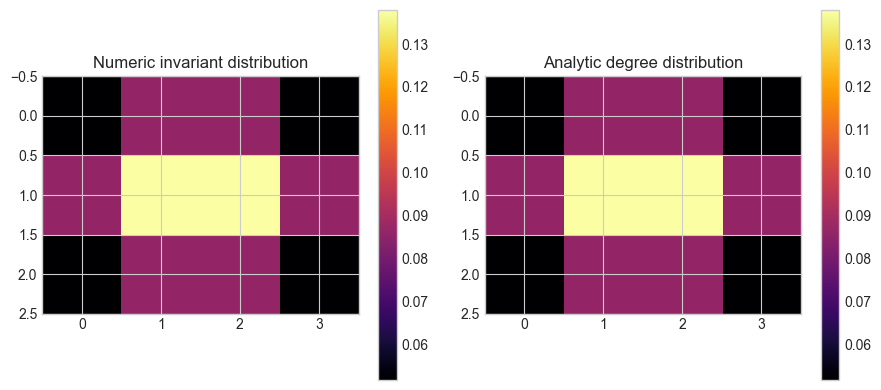

In [3]:
room = Room(3, 4)
cleaner = UniformCleaner(room)
inv_numeric = cleaner.getInvariantDist(reshape=True)
inv_analytic = cleaner.getAnalyticInvariantDist()

print("Transition matrix shape:", cleaner.P.shape)
print("Rows sum to one:", np.allclose(cleaner.P.sum(axis=1), 1))
print("Numeric and analytic invariant distributions match:", np.allclose(inv_numeric, inv_analytic))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].set_title("Numeric invariant distribution")
im0 = axes[0].imshow(inv_numeric, cmap="inferno")
fig.colorbar(im0, ax=axes[0])
axes[1].set_title("Analytic degree distribution")
im1 = axes[1].imshow(inv_analytic, cmap="inferno")
fig.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()


Инвариантное распределение выше в центре комнаты, потому что у внутренних клеток больше соседей. Это совпадает с интуицией: робот чаще попадает в области, из которых есть больше способов войти и выйти.


In [4]:

class Experiment:
    def __init__(self, runName="TemplateRun", M=3, N=3, alpha=2, beta=5, nCleaners=1, aggregators=None):
        self.runName = runName
        self.room = Room(M=M, N=N, alpha=alpha, beta=beta)
        self.cleaners = [UniformCleaner(self.room) for _ in range(nCleaners)]
        self.aggregators = aggregators if aggregators is not None else {"meanDust": np.mean}

    def __str__(self):
        return f"Experiment({self.runName}, room={self.room}, cleaners={len(self.cleaners)})"

    def resetExperiment(self):
        self.room.reset()
        for cleaner in self.cleaners:
            cleaner.reset()

    def makeOneRun(self, maxTime=1000):
        self.resetExperiment()
        results = {key: np.zeros(maxTime) for key in self.aggregators}
        results["dustLevel"] = np.zeros((maxTime, self.room.M, self.room.N), dtype=float)

        for t in range(maxTime):
            # One experimental minute: new dust appears, cleaners move, then we measure remaining dust.
            self.room.addDust()
            for cleaner in self.cleaners:
                cleaner.makeMove()
                self.room.removeDust(cleaner.y, cleaner.x)
            results["dustLevel"][t] = self.room.dustMatrix
            for key, aggregator in self.aggregators.items():
                results[key][t] = self.room.getAggregator(aggregator)
        return results

    def makeManyRuns(self, maxTime=1000, nExperiments=1):
        return [self.makeOneRun(maxTime=maxTime) for _ in range(nExperiments)]


def processExperimentData(runs):
    keys = runs[0].keys()
    return {key: np.mean([run[key] for run in runs], axis=0) for key in keys}


In [5]:

np.random.seed(202602)

aggregators = {"meanDust": np.mean, "maxDust": np.max, "sumDust": np.sum}
configs = [
    {"runName": "5x5 small", "M": 5, "N": 5, "alpha": 2, "beta": 5, "nCleaners": 1, "aggregators": aggregators},
    {"runName": "15x15 large square", "M": 15, "N": 15, "alpha": 2, "beta": 5, "nCleaners": 1, "aggregators": aggregators},
    {"runName": "5x15 large long", "M": 5, "N": 15, "alpha": 2, "beta": 5, "nCleaners": 1, "aggregators": aggregators},
    {"runName": "5x10 medium long", "M": 5, "N": 10, "alpha": 2, "beta": 5, "nCleaners": 1, "aggregators": aggregators},
    {"runName": "10x10 medium square", "M": 10, "N": 10, "alpha": 2, "beta": 5, "nCleaners": 1, "aggregators": aggregators},
]

maxTime = 1000
nRuns = 100

experiments = [Experiment(**config) for config in configs]
results = []

for exp in experiments:
    print("Running", exp.runName)
    runs = exp.makeManyRuns(maxTime=maxTime, nExperiments=nRuns)
    results.append(runs)

expProcessed = [processExperimentData(runs) for runs in results]


Running 5x5 small


Running 15x15 large square


Running 5x15 large long


Running 5x10 medium long


Running 10x10 medium square


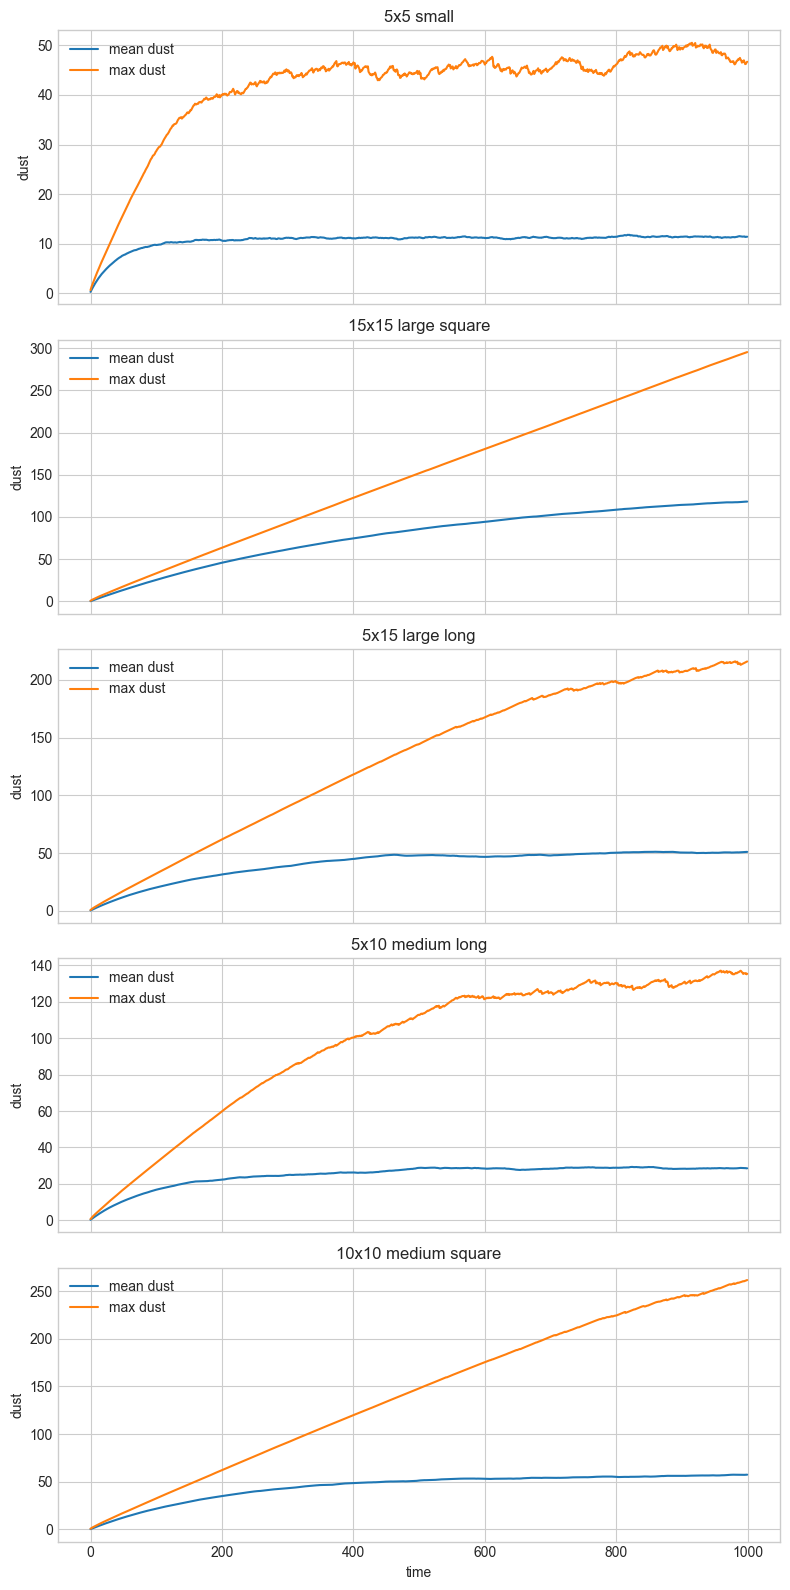

In [6]:
fig, axes = plt.subplots(len(expProcessed), 1, figsize=(8, 3.2 * len(expProcessed)), sharex=True)

for ax, exp, res in zip(axes, experiments, expProcessed):
    ax.set_title(exp.runName)
    ax.plot(res["meanDust"], label="mean dust")
    ax.plot(res["maxDust"], label="max dust")
    ax.set_ylabel("dust")
    ax.legend()

axes[-1].set_xlabel("time")
plt.tight_layout()
plt.show()



**Комментарий.** В малой комнате пыль быстро выходит на сравнительно низкий стационарный уровень: один пылесос регулярно возвращается почти во все клетки. В больших комнатах максимум растет сильнее, потому что среднее время возвращения в конкретную клетку увеличивается. Вытянутая геометрия ухудшает перемешивание: даже при диагональных ходах робот дольше переносит массу посещений между удаленными участками комнаты.


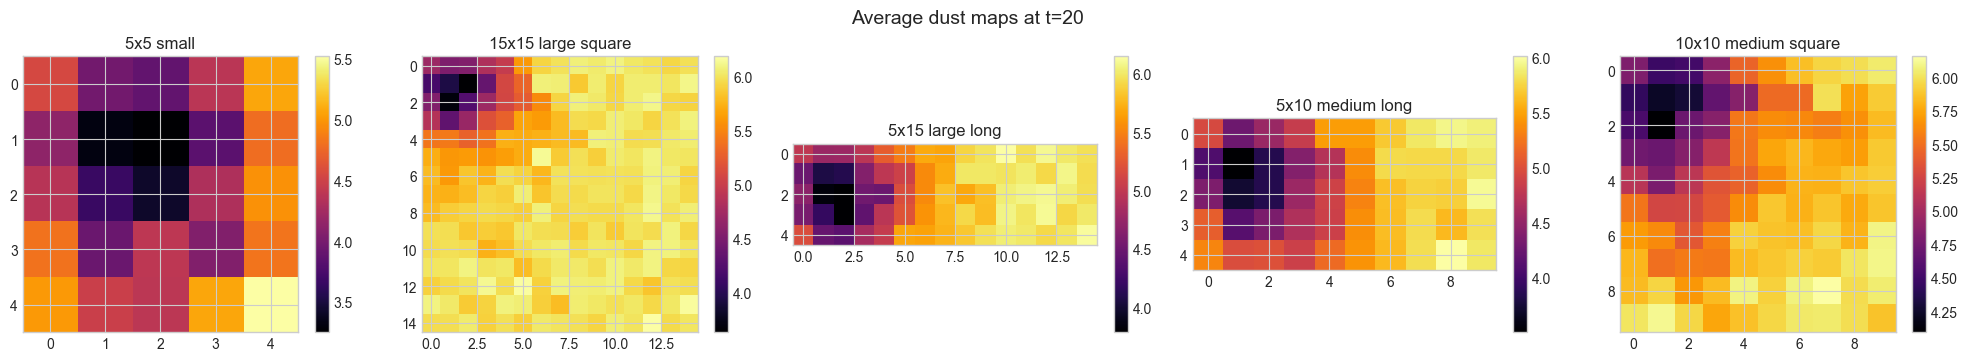

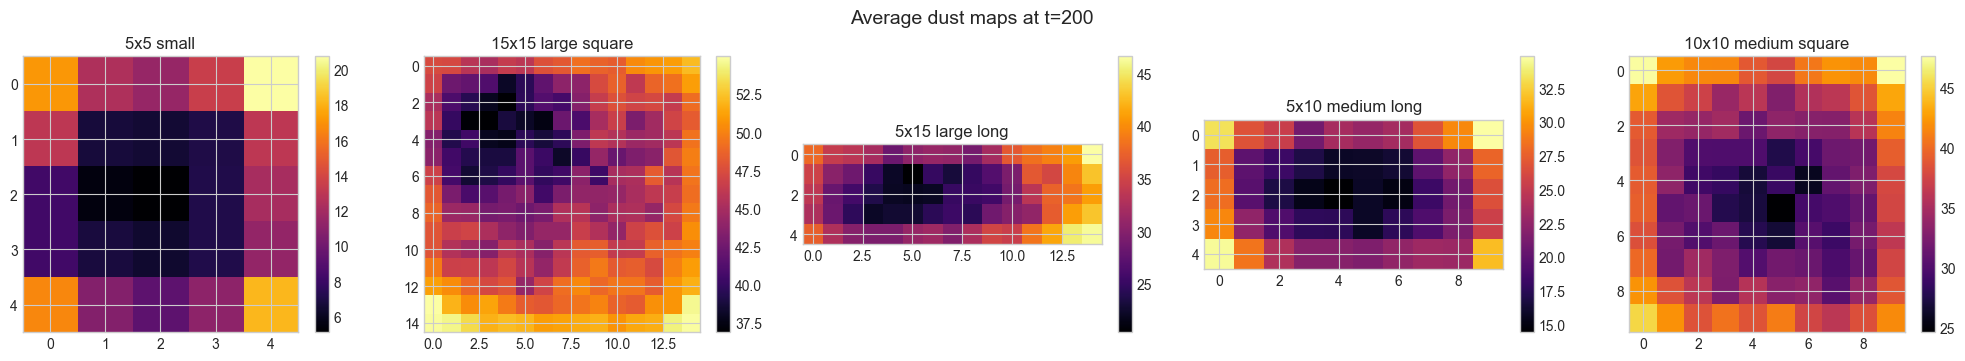

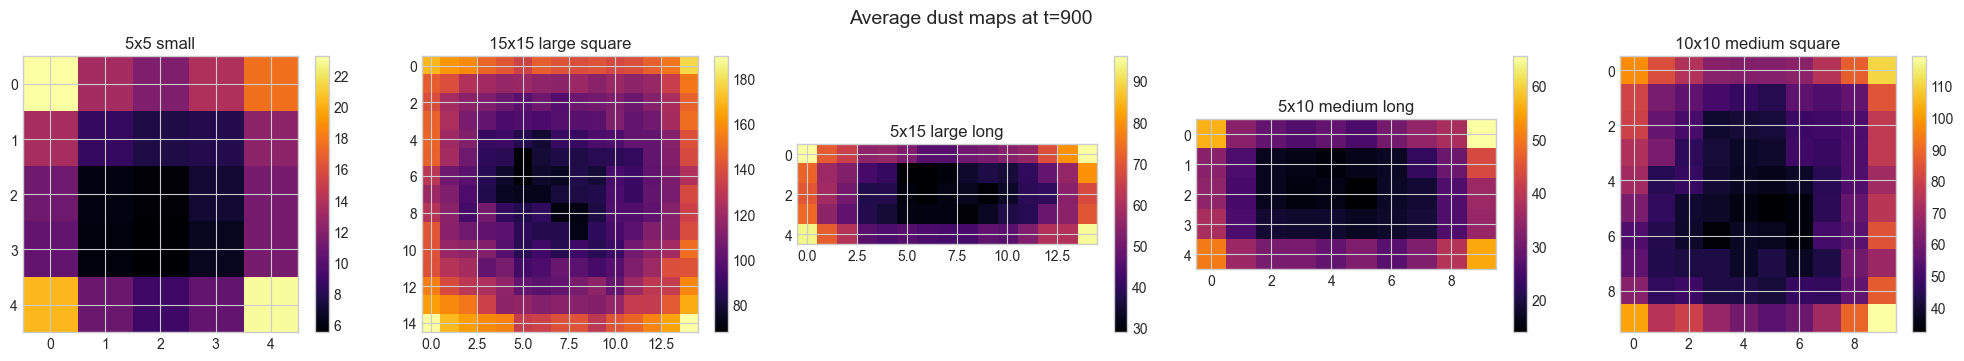

In [7]:
time_slices = [20, 200, 900]

for timeSlice in time_slices:
    fig, axes = plt.subplots(1, len(expProcessed), figsize=(4 * len(expProcessed), 3.5))
    fig.suptitle(f"Average dust maps at t={timeSlice}", fontsize=14)
    for ax, exp, res in zip(axes, experiments, expProcessed):
        ax.set_title(exp.runName)
        im = ax.imshow(res["dustLevel"][timeSlice], cmap="inferno")
        fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()



На картах больше всего пыли видно в областях, куда робот приходит реже или куда он долго возвращается после ухода. Углы и дальние края часто оказываются более проблемными, потому что у них меньше соседей и ниже стационарная вероятность посещения. Для больших комнат центральная область посещается чаще, но одного робота все равно мало: локальные максимумы пыли возникают из-за больших времен между посещениями.


### Длинная комната $3\times30$

Проверим отдельно, как робот справляется с очень вытянутой геометрией.


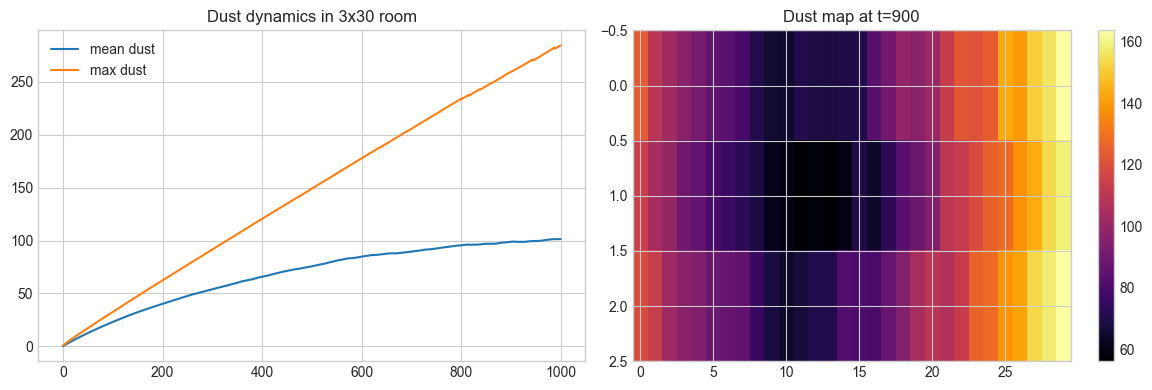

In [8]:
long_exp = Experiment(
    runName="3x30 very long",
    M=3,
    N=30,
    alpha=2,
    beta=5,
    nCleaners=1,
    aggregators=aggregators,
)
long_runs = long_exp.makeManyRuns(maxTime=maxTime, nExperiments=nRuns)
long_processed = processExperimentData(long_runs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].set_title("Dust dynamics in 3x30 room")
axes[0].plot(long_processed["meanDust"], label="mean dust")
axes[0].plot(long_processed["maxDust"], label="max dust")
axes[0].legend()

axes[1].set_title("Dust map at t=900")
im = axes[1].imshow(long_processed["dustLevel"][900], cmap="inferno", aspect="auto")
fig.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()


Длинная комната хуже квадратной сопоставимой площади: робот часто локально блуждает и долго добирается до дальних концов. Поэтому максимум пыли определяется не только площадью, но и временем перемешивания марковской цепи.



### Несколько пылесосов

Проверим, сколько пылесосов нужно в комнате $15\times15$, чтобы средний максимум пыли был не выше $200$. Для вытянутой комнаты дополнительно посмотрим длинный пример $3\times30$: площадь у него меньше, чем у $15\times15$, но геометрия хуже для перемешивания.


In [9]:

np.random.seed(202603)

cleaner_counts = [1, 2, 3, 4, 5, 6, 8, 10]

multi_results_square = []
for nCleaners in cleaner_counts:
    exp = Experiment(
        runName=f"15x15, cleaners={nCleaners}",
        M=15,
        N=15,
        alpha=2,
        beta=5,
        nCleaners=nCleaners,
        aggregators=aggregators,
    )
    processed = processExperimentData(exp.makeManyRuns(maxTime=maxTime, nExperiments=60))
    multi_results_square.append((nCleaners, processed))
    print(nCleaners, "cleaners, final average max dust:", processed["maxDust"][-200:].mean())

square_final_max = np.array([res["maxDust"][-200:].mean() for _, res in multi_results_square])
needed = next((n for n, value in zip(cleaner_counts, square_final_max) if value <= 200), None)
print("Needed cleaners for 15x15 threshold 200:", needed)


1 cleaners, final average max dust: 267.42735354900987


2 cleaners, final average max dust: 263.1999304805758


3 cleaners, final average max dust: 235.4256302512735


4 cleaners, final average max dust: 206.75916448300697


5 cleaners, final average max dust: 182.7139194188013


6 cleaners, final average max dust: 154.8276005190958


8 cleaners, final average max dust: 108.45017276912814


10 cleaners, final average max dust: 88.74680542179303
Needed cleaners for 15x15 threshold 200: 5


In [10]:

np.random.seed(202604)

multi_results_long = []
for nCleaners in cleaner_counts:
    exp = Experiment(
        runName=f"3x30, cleaners={nCleaners}",
        M=3,
        N=30,
        alpha=2,
        beta=5,
        nCleaners=nCleaners,
        aggregators=aggregators,
    )
    processed = processExperimentData(exp.makeManyRuns(maxTime=maxTime, nExperiments=60))
    multi_results_long.append((nCleaners, processed))
    print(nCleaners, "cleaners, final average max dust:", processed["maxDust"][-200:].mean())

long_final_max = np.array([res["maxDust"][-200:].mean() for _, res in multi_results_long])
needed_long = next((n for n, value in zip(cleaner_counts, long_final_max) if value <= 200), None)
print("Needed cleaners for 3x30 threshold 200:", needed_long)


1 cleaners, final average max dust: 258.9792286831443


2 cleaners, final average max dust: 193.17641132854777


3 cleaners, final average max dust: 139.10653224332106


4 cleaners, final average max dust: 109.95986244671006


5 cleaners, final average max dust: 89.0700906971555


6 cleaners, final average max dust: 62.08618347373935


8 cleaners, final average max dust: 47.82045065088776


10 cleaners, final average max dust: 32.812160092996905
Needed cleaners for 3x30 threshold 200: 2


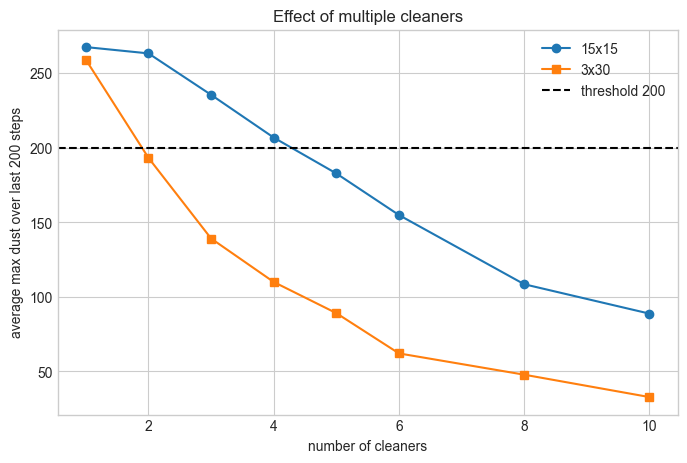

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title("Effect of multiple cleaners")
ax.plot(cleaner_counts, square_final_max, "o-", label="15x15")
ax.plot(cleaner_counts, long_final_max, "s-", label="3x30")
ax.axhline(200, color="black", linestyle="--", label="threshold 200")
ax.set_xlabel("number of cleaners")
ax.set_ylabel("average max dust over last 200 steps")
ax.legend()
plt.show()



**Комментарий.** Для комнаты $15\times15$ несколько пылесосов действительно помогают: максимум падает почти монотонно с ростом числа роботов, потому что суммарная частота посещения клеток растет. В нашем воспроизводимом прогоне минимальное число роботов для порога $200$ выводится в ячейке выше.

Для длинной комнаты добавление роботов тоже помогает, но геометрическая проблема не исчезает: если все роботы стартуют из одного угла и используют одинаковое локальное случайное правило, дальние зоны все еще покрываются хуже, чем при специально спроектированной стратегии. Поэтому "просто добавить роботов" работает количественно, но алгоритмически это не самое умное решение; лучше распределять стартовые позиции или добавлять направленное исследование.


### Бонус: столкновения

Если учитывать столкновения, состояние цепи должно включать позиции всех пылесосов:
$$
((y_1,x_1),\ldots,(y_k,x_k)).
$$
Если запрещать двум роботам находиться в одной клетке, пространство состояний уменьшается до наборов различных клеток, но переходное правило становится зависимым: выбранные ходы нужно согласовывать централизованно.

Один естественный вариант: каждый робот предлагает ход, затем конфликтующие предложения отклоняются, и соответствующие роботы остаются на месте. Такая модель уже не равна произведению независимых цепей: переход одного робота зависит от предложений остальных. Инвариантное распределение можно искать численно для маленьких комнат, но для больших комнат размер пространства состояний порядка $(MN)^k$, поэтому прямой тензор быстро становится непрактичным.



## Дополнительная часть. Американские опционы и верхняя оценка

### Новый мартингал

Пусть $M_t$ - мартингал относительно $\mathcal F_t^X$ с $M_0=0$ и $\mathbb E M_t=0$. Горизонт здесь конечный и дискретный, поэтому для любого допустимого момента остановки $\tau$ теорема об остановке дает
$$
\mathbb E M_\tau=0.
$$
Тогда
$$
\mathbb E[e^{-r\tau_*}f(X_{\tau_*})]
=\mathbb E[e^{-r\tau_*}f(X_{\tau_*})-M_{\tau_*}].
$$
Для каждой траектории значение в момент $\tau_*$ не превосходит максимума по всем моментам:
$$
e^{-r\tau_*}f(X_{\tau_*})-M_{\tau_*}
\le \max_t(e^{-rt}f(X_t)-M_t).
$$
Берем матожидание:
$$
\mathbb E[e^{-r\tau_*}f(X_{\tau_*})]
\le \mathbb E\max_t(e^{-rt}f(X_t)-M_t).
$$
Так верно для любого подходящего мартингала $M$, значит верно и для инфимума по $M\in\mathcal M$.



### Построение мартингала

Пусть
$$
Y_t=V_t(X_t)-\mathbb E[V_t(X_t)\mid X_{t-1}].
$$
Тогда
$$
\mathbb E[Y_t\mid\mathcal F_{t-1}]=0.
$$
Следовательно,
$$
M_t=\sum_{j=1}^tY_j
$$
является мартингалом:
$$
\mathbb E[M_t\mid\mathcal F_{t-1}]
=M_{t-1}+\mathbb E[Y_t\mid\mathcal F_{t-1}]
=M_{t-1}.
$$

Аккуратнее всего записывать двойственную формулу для дисконтированного Snell envelope:
$$
U_t=e^{-rt}V_t(X_t).
$$
Для оптимального мартингала из разложения Дуба имеем
$$
U_0=\mathbb E\max_{t=1,\ldots,T}\left(e^{-rt}f(X_t)-M_t\right).
$$
Если $X_0$ фиксирован, то $U_0=V_0(X_0)$ - константа. Для приближенного мартингала равенства уже нет, но предыдущее неравенство дает верхнюю оценку.

В коде ниже $\hat V_t$ строится из регрессионного метода, а условное матожидание в мартингальном приращении оценивается вложенными одношаговыми симуляциями:
$$
\hat Y_t=\hat V_t(X_t)-\frac1K\sum_{j=1}^K\hat V_t(\widetilde X_t^{\,j}),
$$
где $\widetilde X_t^{\,j}$ стартуют из $X_{t-1}$.


In [12]:
class PolynomialFeatureMap:
    def __init__(self, degree=2):
        self.degree = degree
        self.combinations = None

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        d = X.shape[1]
        self.combinations = [()]
        for deg in range(1, self.degree + 1):
            self.combinations.extend(combinations_with_replacement(range(d), deg))
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        if self.combinations is None:
            self.fit(X)
        cols = []
        for combo in self.combinations:
            if len(combo) == 0:
                cols.append(np.ones(X.shape[0]))
            else:
                cols.append(np.prod(X[:, combo], axis=1))
        return np.column_stack(cols)

    def fit_transform(self, X):
        return self.fit(X).transform(X)


class ValueFunction:
    def __init__(self, deg=2):
        self.featureTransform = PolynomialFeatureMap(degree=deg)
        self.coef_ = None

    def fit(self, X, y):
        X_poly = self.featureTransform.fit_transform(X)
        self.coef_, *_ = np.linalg.lstsq(X_poly, np.asarray(y).ravel(), rcond=None)
        return self

    def predict(self, X):
        X_poly = self.featureTransform.transform(X)
        return X_poly @ self.coef_

    def getParameters(self):
        return self.coef_


def simulateWienerProcessMultivar(x0, ts, Ntraj):
    x0 = np.asarray(x0, dtype=float)
    ts = np.asarray(ts, dtype=float)
    d = x0.shape[0]
    xs = np.zeros((Ntraj, d, len(ts)))
    xs[:, :, 0] = x0[None, :]
    dts = np.diff(ts)
    increments = np.random.normal(0.0, np.sqrt(dts)[None, None, :], size=(Ntraj, d, len(ts) - 1))
    xs[:, :, 1:] = x0[None, :, None] + np.cumsum(increments, axis=2)
    return xs


class GBMModelMultivar:
    def __init__(self, mu=0, sigma=1):
        self.mu = np.asarray(mu, dtype=float)
        self.sigma = np.asarray(sigma, dtype=float)

    def simulate(self, x0, ts, Ntraj):
        x0 = np.asarray(x0, dtype=float)
        ts = np.asarray(ts, dtype=float)
        rel_ts = ts - ts[0]
        w = simulateWienerProcessMultivar(np.zeros_like(x0), rel_ts, Ntraj)
        drift = (self.mu - 0.5 * self.sigma**2)[None, :, None] * rel_ts[None, None, :]
        diffusion = self.sigma[None, :, None] * w
        return x0[None, :, None] * np.exp(drift + diffusion)

    def oneStepSimulation(self, x0, dt):
        x0 = np.asarray(x0, dtype=float)
        noise = np.random.normal(size=x0.shape)
        exponent = (self.mu - 0.5 * self.sigma**2) * dt + self.sigma * np.sqrt(dt) * noise
        return x0 * np.exp(exponent)


In [13]:

class OptionPricer:
    def __init__(self, priceModel, payment, executionTimes, discountFunction):
        self.priceModel = priceModel
        self.payment = payment
        self.executionTimes = np.asarray(executionTimes, dtype=float)
        self.discountFunction = discountFunction
        self.continuationModels = [ValueFunction(deg=2) for _ in range(len(executionTimes) - 2)]
        self.upperTrajs = None

    def _fit_continuation(self, model, X, y, immediate):
        in_the_money = immediate > 0
        if np.sum(in_the_money) >= 10:
            model.fit(X[in_the_money], y[in_the_money])
        else:
            model.fit(X, y)

    def value_hat(self, k, X):
        p = len(self.executionTimes) - 1
        if k == p:
            return self.payment(X)
        if k == 0:
            raise ValueError("value_hat is used for k >= 1")
        immediate = self.payment(X)
        continuation = self.continuationModels[k - 1].predict(X)
        return np.maximum(immediate, continuation)

    def computeHighBiasEstimator(self, Ntrajs, x0, saveTraj=False):
        paths = self.priceModel.simulate(x0, self.executionTimes, Ntrajs)
        p = len(self.executionTimes) - 1
        values = self.payment(paths[:, :, p])

        for k in range(p - 1, 0, -1):
            dt = self.executionTimes[k + 1] - self.executionTimes[k]
            discounted_next = self.discountFunction(dt) * values
            Xk = paths[:, :, k]
            immediate = self.payment(Xk)
            model = self.continuationModels[k - 1]
            self._fit_continuation(model, Xk, discounted_next, immediate)
            continuation = model.predict(Xk)
            exercise = (immediate > 0) & (immediate >= continuation)
            values = np.where(exercise, immediate, discounted_next)

        first_dt = self.executionTimes[1] - self.executionTimes[0]
        samples = self.discountFunction(first_dt) * values
        immediate0 = float(self.payment(np.asarray(x0)[None, :])[0])
        if immediate0 > float(np.mean(samples)):
            samples = np.full(Ntrajs, immediate0)

        if saveTraj:
            self.upperTrajs = paths
        return float(np.mean(samples)), float(np.std(samples, ddof=1) / np.sqrt(Ntrajs))

    def computeLowEstimator(self, Ntrajs, x0):
        paths = self.priceModel.simulate(x0, self.executionTimes, Ntrajs)
        p = len(self.executionTimes) - 1
        rewards = np.zeros(Ntrajs)
        alive = np.ones(Ntrajs, dtype=bool)

        for k in range(1, p):
            Xk = paths[:, :, k]
            immediate = self.payment(Xk)
            continuation = self.continuationModels[k - 1].predict(Xk)
            exercise = alive & (immediate > 0) & (immediate >= continuation)
            rewards[exercise] = self.discountFunction(self.executionTimes[k]) * immediate[exercise]
            alive[exercise] = False

        if np.any(alive):
            terminal = self.payment(paths[alive, :, p])
            rewards[alive] = self.discountFunction(self.executionTimes[p]) * terminal

        immediate0 = float(self.payment(np.asarray(x0)[None, :])[0])
        if immediate0 > float(np.mean(rewards)):
            rewards = np.full(Ntrajs, immediate0)
        return float(np.mean(rewards)), float(np.std(rewards, ddof=1) / np.sqrt(Ntrajs))

    def computeUpperEstimator(self, K=5, Ntrajs=None, x0=None):
        if Ntrajs is not None:
            if x0 is None:
                raise ValueError("x0 is required when Ntrajs is passed")
            paths = self.priceModel.simulate(x0, self.executionTimes, Ntrajs)
        elif self.upperTrajs is not None:
            paths = self.upperTrajs
        else:
            raise ValueError("Pass Ntrajs and x0, or call computeHighBiasEstimator(..., saveTraj=True)")

        Ntrajs = paths.shape[0]
        p = len(self.executionTimes) - 1
        martingale = np.zeros(Ntrajs)
        candidates = []

        for k in range(1, p + 1):
            t = self.executionTimes[k]
            dt = self.executionTimes[k] - self.executionTimes[k - 1]
            X_prev = paths[:, :, k - 1]
            X_now = paths[:, :, k]

            actual_value = self.value_hat(k, X_now)
            nested_start = np.repeat(X_prev[:, None, :], K, axis=1)
            nested_next = self.priceModel.oneStepSimulation(nested_start, dt)
            nested_value = self.value_hat(k, nested_next.reshape(Ntrajs * K, -1)).reshape(Ntrajs, K).mean(axis=1)

            martingale += self.discountFunction(t) * (actual_value - nested_value)
            candidates.append(self.discountFunction(t) * self.payment(X_now) - martingale)

        upper_samples = np.max(np.column_stack(candidates), axis=1)
        return float(np.mean(upper_samples)), float(np.std(upper_samples, ddof=1) / np.sqrt(Ntrajs))


In [14]:
a = 0
b = 1
Nt = 10
h = (b - a) / Nt
ts = np.arange(a, b + h / 2, h)

r = 0.05
delta = 0.1
mu = (r - delta) * np.ones(2)
sigma = 0.2 * np.ones(2)
K_strike = 100

gbm = GBMModelMultivar(mu, sigma)


def basketPayment(x):
    x = np.asarray(x, dtype=float)
    return np.maximum(np.max(x, axis=1) - K_strike, 0.0)


def expDiscount(h):
    return np.exp(-r * h)


trr = gbm.simulate(np.array([100, 100]), ts, 20)
oneSteps = np.concatenate(
    [
        gbm.oneStepSimulation(trr[:, None, :, kk - 1] * np.ones((1, 15, 1)), ts[kk] - ts[kk - 1])[..., None]
        for kk in range(1, len(ts))
    ],
    axis=-1,
)
print("Nested one-step simulations shape:", oneSteps.shape)


Nested one-step simulations shape: (20, 15, 2, 10)


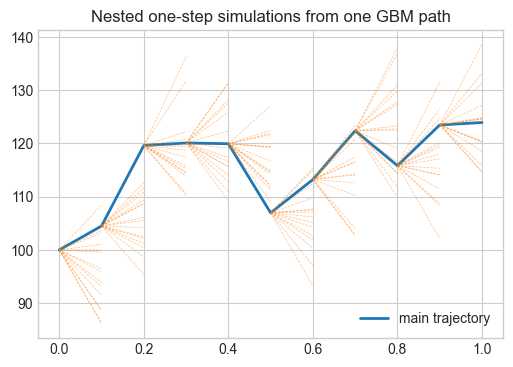

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.set_title("Nested one-step simulations from one GBM path")
trajId = 5
ax.plot(ts, trr[trajId, 0, :].T, lw=2, label="main trajectory")
for t_id in range(len(ts) - 1):
    plotAr = np.array(
        [
            np.ones_like(oneSteps[trajId, :, 0, t_id]) * trr[trajId, 0, t_id],
            oneSteps[trajId, :, 0, t_id],
        ]
    )
    ax.plot(ts[t_id : (t_id + 2)], plotAr, "--", linewidth=0.5, color="tab:orange", alpha=0.5)
ax.legend()
plt.show()


In [16]:

np.random.seed(202605)

N_train_grid = [500, 1000, 2000, 4000, 8000, 16000]
N_test = 40_000
N_upper = 8_000
scenarios = {
    "x0 = [100, 100]": np.array([100, 100]),
    "x0 = [110, 110]": np.array([110, 110]),
    "x0 = [90, 90]": np.array([90, 90]),
}

option_results = {}

for label, x0 in scenarios.items():
    print(label)
    rows = []
    for N_train in N_train_grid:
        pricer = OptionPricer(gbm, basketPayment, ts, expDiscount)
        high, high_se = pricer.computeHighBiasEstimator(N_train, x0)
        low, low_se = pricer.computeLowEstimator(N_test, x0)
        upper, upper_se = pricer.computeUpperEstimator(K=10, Ntrajs=N_upper, x0=x0)
        rows.append((N_train, high, high_se, low, low_se, upper, upper_se))
        print(
            f"  N={N_train:5d}: low={low:7.4f}, high={high:7.4f}, upper={upper:7.4f}"
        )
    option_results[label] = np.array(rows, dtype=float)


x0 = [100, 100]


  N=  500: low=10.1220, high=11.9459, upper=11.5717
  N= 1000: low=10.0144, high=10.1343, upper=11.5690


  N= 2000: low=10.1755, high=10.7918, upper=11.5972
  N= 4000: low=10.1089, high=10.1806, upper=11.4916


  N= 8000: low=10.2097, high=10.1924, upper=11.4934
  N=16000: low=10.1910, high=10.2937, upper=11.4914
x0 = [110, 110]


  N=  500: low=18.1574, high=19.2791, upper=20.4571
  N= 1000: low=18.3413, high=18.7788, upper=20.5407


  N= 2000: low=18.4445, high=18.4461, upper=20.2907
  N= 4000: low=18.2737, high=18.6032, upper=20.4419


  N= 8000: low=18.2703, high=18.3603, upper=20.3924
  N=16000: low=18.3709, high=18.4692, upper=20.3225
x0 = [90, 90]


  N=  500: low= 4.2717, high= 4.5729, upper= 5.3804
  N= 1000: low= 4.2515, high= 4.6211, upper= 6.0668


  N= 2000: low= 4.3949, high= 4.1977, upper= 5.1404
  N= 4000: low= 4.3767, high= 4.4960, upper= 5.1419


  N= 8000: low= 4.4218, high= 4.2784, upper= 5.0817
  N=16000: low= 4.4244, high= 4.3976, upper= 5.0917


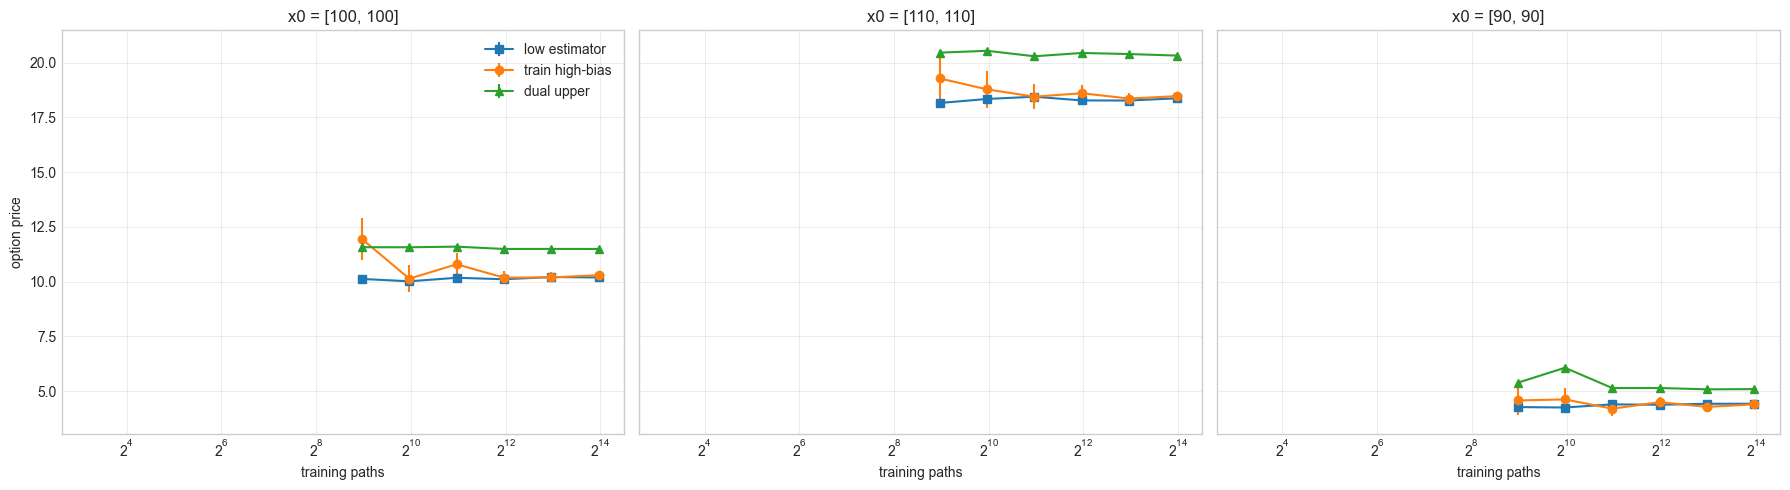

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (label, rows) in zip(axes, option_results.items()):
    Ns = rows[:, 0]
    high, high_ci = rows[:, 1], 1.96 * rows[:, 2]
    low, low_ci = rows[:, 3], 1.96 * rows[:, 4]
    upper, upper_ci = rows[:, 5], 1.96 * rows[:, 6]

    ax.set_title(label)
    ax.set_xscale("log", base=2)
    ax.errorbar(Ns, low, yerr=low_ci, marker="s", label="low estimator")
    ax.errorbar(Ns, high, yerr=high_ci, marker="o", label="train high-bias")
    ax.errorbar(Ns, upper, yerr=upper_ci, marker="^", label="dual upper")
    ax.set_xlabel("training paths")
    ax.grid(True, which="both", alpha=0.35)

axes[0].set_ylabel("option price")
axes[0].legend()
plt.tight_layout()
plt.show()



**Комментарий к опционам.** Нижняя оценка получается из честного правила остановки на новых траекториях. Оценка на обучающих траекториях обычно выше из-за подгонки правила под те же данные. Двойственная верхняя оценка строится через приближенный мартингал и независимый набор траекторий для оценки максимума; она может быть шумной, но дает полезный верхний ориентир. При росте числа обучающих траекторий зазор между нижней и верхней оценками в среднем должен уменьшаться, хотя на конечном Монте-Карло это не обязано быть монотонным.
